In [2]:
# Put import statements here
import os
# hide tensorflow info/warning logs
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import sys
import subprocess
from pathlib import Path

# Local files/code
import src.data_preprocessing.image_data_exploration as img_explore
import src.data_preprocessing.text_preprocessing as text_pre
import src.data_preprocessing.text_data_exploration as text_explore
from src.agents.Visual_Agent import VisualModel
from src.util.logger import Logger
from src.util.config import config, PROJECT_ROOT
from data_preprocessing.USDA_processing import process_USDA_plant_sheets

import src.util.general as general_util
from src.data_preprocessing.TextTokenizer import TextTokenizer
from src.data_preprocessing.TextEmbedder import TextEmbedder
import src.evaluation.visual_evaluator as visual_evaluator

In [3]:
# Determine the project's data repo location
DATA_DIR= PROJECT_ROOT / "data"


In [4]:

# example of how to chunk+vectorize text data

USDA_data_path= DATA_DIR / "EOI_Data_Pulls"
USDA_plant_sheets_path= USDA_data_path / "plant_sheets"
temp= USDA_plant_sheets_path / "ABBA/ABBA_1.pdf"

# load and clean the text data however you need to
text= text_pre.load_pdf_text_data(temp)
text= text_pre.replace_urls(text, "url")
text= text.replace("<", "")
text= text.replace(">", "")

# make the text embedder
embedder= TextEmbedder("sentence-transformers/all-MiniLM-L6-v2")

CHUNK_METHOD= "word" # word or sentence
CHUNK_MAX_SIZE= 64
CHUNK_OVERLAP_AMOUNT= 16

# chunk and encode
records= embedder.chunk_and_encode(text, CHUNK_METHOD, CHUNK_MAX_SIZE, CHUNK_OVERLAP_AMOUNT)
# This takes ~30sec - 1.5min to run
# parse the USDA plant sheets, chunk them, vectorize them, and make organized records
# Also chunk/vectorize USDA json files that have relevant plant sheets
# NOTE: the PDF parsing library loves to spit out annoying logs
#       I've tried to supress them a million ways, but could not get it to stop
#       The logs are annoying but superficial
records= process_USDA_plant_sheets(
    USDA_data_path,
    embedder,
    CHUNK_METHOD,
    CHUNK_MAX_SIZE,
    CHUNK_OVERLAP_AMOUNT
)

# review records
for record in records:
    Logger.info(f"\n{record}")



11:35:37 [ERROR   ]: [load_csv] Unable to open /mnt/c/Users/codyr/Code/AI-572/PlantQA/data/EOI_Data_Pulls/plant_sheets/ABBA/ABBA_1.pdf.


TypeError: expected string or bytes-like object, got 'NoneType'

In [5]:
# Example of one of the records for one chunk of a plant
Logger.info(f"records type: {type(records)}")
Logger.info(f"records len: {len(records)}")
Logger.info(f"Example of a pdf chunk record: \n\n{records['ABBA'][0]}")
Logger.info(f"Example of a json record: \n\n{records['ABBA'][-1]}")

NameError: name 'records' is not defined

In [6]:
# load the plantExpertVQA training, validation, and testing datasets
plant_expert_vqa_data_path= DATA_DIR / config.data.PlantExpertVQA.data_path
plant_expert_vqa_path= DATA_DIR / "PlantExpertVQA"
train_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.train_file
test_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.test_file
validation_data_path= plant_expert_vqa_data_path / config.data.PlantExpertVQA.validation_file


plant_expert_vqa_TRAIN= text_pre.load_csv(train_data_path)
plant_expert_vqa_TEST= text_pre.load_csv(test_data_path)
plant_expert_vqa_VAL= text_pre.load_csv(validation_data_path)

11:35:52 [DEBUG   ]: [load_csv] Successfully loaded /mnt/c/Users/codyr/Code/AI-572/PlantQA/data/PlantExpertVQA/data/train.csv into dataframe


/mnt/c/Users/codyr/Code/AI-572/PlantQA/src/data_preprocessing/text_preprocessing.py:48: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  data= pd.read_csv(csv_path)


11:35:53 [DEBUG   ]: [load_csv] Successfully loaded /mnt/c/Users/codyr/Code/AI-572/PlantQA/data/PlantExpertVQA/data/test.csv into dataframe
11:35:53 [DEBUG   ]: [load_csv] Successfully loaded /mnt/c/Users/codyr/Code/AI-572/PlantQA/data/PlantExpertVQA/data/val.csv into dataframe


In [ ]:

# Get the configured preprocessing parameters
PEVQA_text_columns= general_util.parse_list_from_string(config.data.PlantExpertVQA.text_columns)
PEVQA_columns_to_remove= general_util.parse_list_from_string(config.data.PlantExpertVQA.columns_to_remove)
PEVQA_na_fill= vars(config.data.PlantExpertVQA.na_fill)

# preprocess (not tokenize) the training, testing, and validation datasets
# NOTE: the stop word removal may be too intense.  We most likely want to fine tune the stopword set, or define our own set
#       Right now it removes words like "what" and "why", which will most likely be bad for a VQA system that answers questions.

# training
text_pre.preprocess_dataframe(
    plant_expert_vqa_TRAIN,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill,
    ["image_path"],
    plant_expert_vqa_path,
)

# testing
text_pre.preprocess_dataframe(
    plant_expert_vqa_TEST,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill,
    ["image_path"],
    plant_expert_vqa_path,
)

#validation
text_pre.preprocess_dataframe(
    plant_expert_vqa_VAL,
    PEVQA_text_columns,
    PEVQA_columns_to_remove,
    PEVQA_na_fill,
    ["image_path"],
    plant_expert_vqa_path,
)


In [ ]:

column_distribution_args= [
    {"column": "crop", "show_counts": False, "figure_size": (10, 5)},
    {"column": "severity", "show_counts": True, "figure_size": (5, 5)},
    {"column": "category", "show_counts": True, "figure_size": (5, 5)},
    {"column": "answer_type", "show_counts": True, "figure_size": (5, 5)},
    {"column": "question_category", "show_counts": False, "figure_size": (10, 5)},
]

# explore the cleaned training dataset
text_explore.explore_data(
    plant_expert_vqa_TRAIN, 
    column_distribution_args, 
    PEVQA_text_columns, 
    top_n_words=20, 
    name="Plant Expert VQA Training Dataset"
)

In [ ]:
# Testing the tokenizer and showing how to use it

# intialize the tokenizer
tokenizer= TextTokenizer("distilbert-base-uncased", 128)

# example of the passing in a single string to tokenize
inputs, attention_mask= tokenizer.encode_text("hello")
Logger.info(inputs)

# how to decode a single tensor output
output= tokenizer.decode(inputs)
Logger.info(output)

# encoding a list of strings
inputs, attention_mask= tokenizer.encode_text(["hello", "this is a test", "i am putting in multiple strings"])
Logger.info(inputs)

# decoding a list of tensors
output= tokenizer.batch_decode(inputs)
Logger.info(output)

# encoding a column of data
questions= plant_expert_vqa_TRAIN["question_text"]
inputs, attention_mask= tokenizer.encode_text(questions)

# decoding a all of those tensors
output= tokenizer.batch_decode(inputs)
Logger.info(f"first few decoded Tensors: \n\n{output[:10]}")


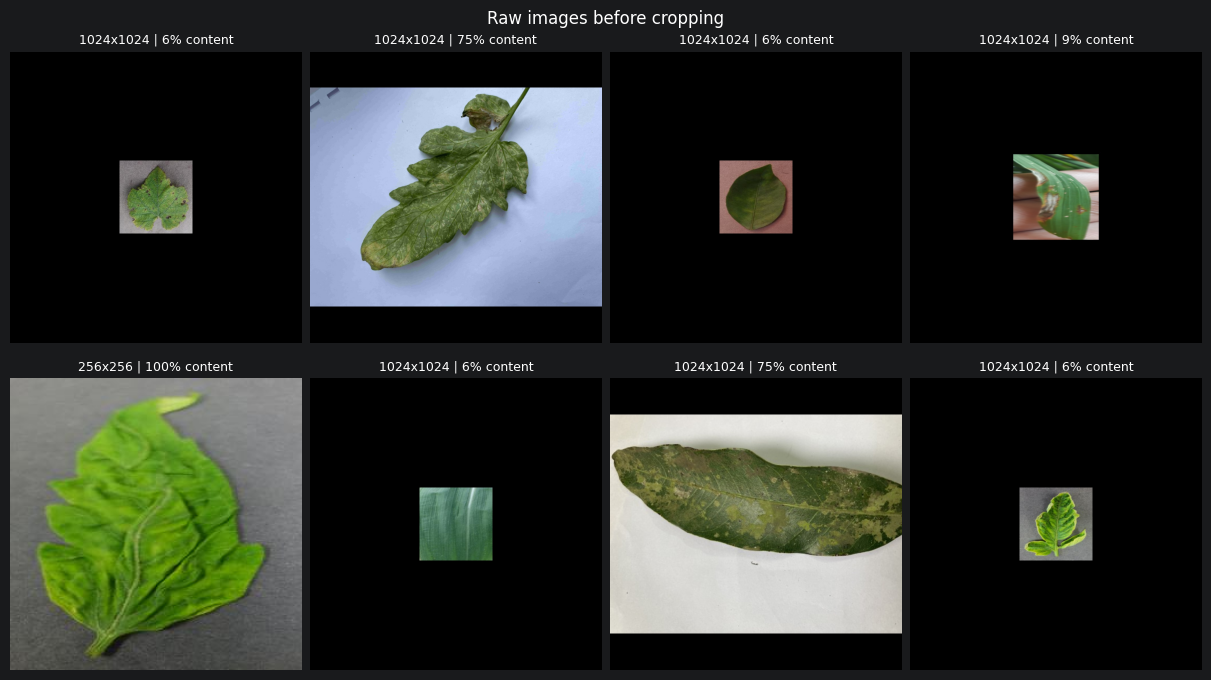

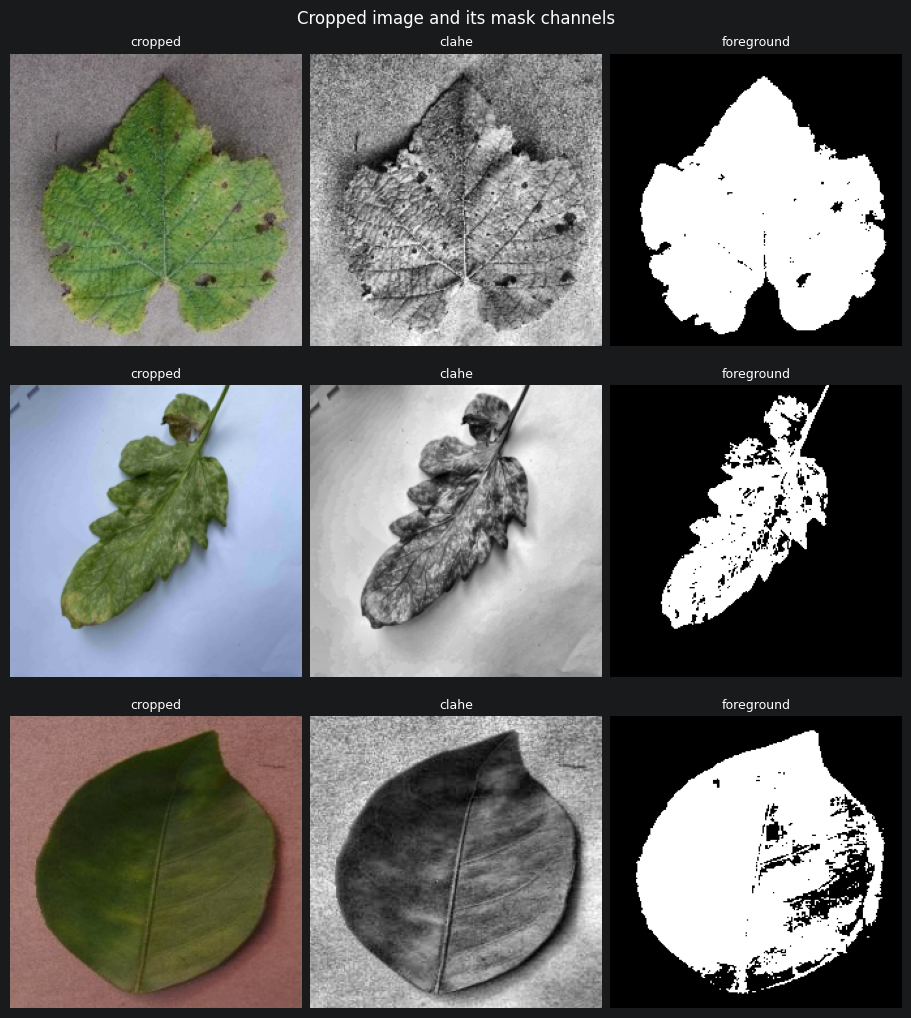

In [7]:
# Most of the images are a small photo pasted onto a large blank canvas, so we crop before resizing
img_explore.show_padding(plant_expert_vqa_TRAIN, plant_expert_vqa_path, count=8)

# The cropped image next to the two channels the mask branch receives
img_explore.show_cropped_and_mask(plant_expert_vqa_TRAIN, plant_expert_vqa_path, count=3)

In [8]:
IMAGES_ROOT = DATA_DIR / "PlantExpertVQA"
traits = ["crop", "disease", "severity"]
train_img = VisualModel.one_row_per_image(plant_expert_vqa_TRAIN, traits)
val_img = VisualModel.one_row_per_image(plant_expert_vqa_VAL, traits)
test_img = VisualModel.one_row_per_image(plant_expert_vqa_TEST, traits)
classes = VisualModel.build_classes(train_img, traits)

train_ds = VisualModel.make_dataset(train_img, classes, IMAGES_ROOT, training=True)
val_ds = VisualModel.make_dataset(val_img, classes, IMAGES_ROOT)

# every image shows up once per question, and those rows do not always agree on a label
img_explore.show_label_conflicts(plant_expert_vqa_TRAIN, traits)

I0000 00:00:1789832184.534294    6702 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13495 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


question rows: 535881   unique images: 105586   rows per image: 5.1
crop: 22551 images carry more than one label
disease: 20214 images carry more than one label
severity: 8995 images carry more than one label


          classes  median_per_class  classes_under_100
crop           38              1145                  2
disease        94               318                 30
severity        5             25740                  0


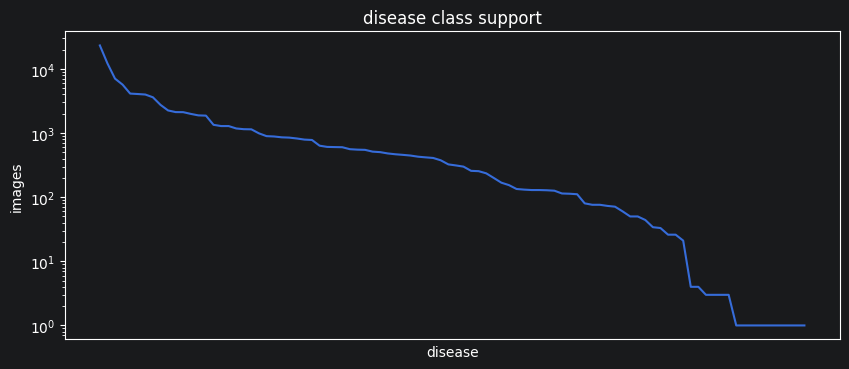

In [9]:
# disease has a long tail of classes with very few images
support = img_explore.show_class_support(train_img, traits)

Epoch 1/20


I0000 00:00:1789832202.641976    6926 service.cc:152] XLA service 0x7f620c001780 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789832202.642049    6926 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 SUPER, Compute Capability 8.9
I0000 00:00:1789832203.599122    6926 cuda_dnn.cc:529] Loaded cuDNN version 92400
2026-09-19 11:36:47.471583: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 11:36:47.646692: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 11:36:47.835805: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-opti

   3/3300 ━━━━━━━━━━━━━━━━━━━━ 3:05 56ms/step - crop_accuracy: 0.0625 - crop_loss: 3.5876 - disease_accuracy: 0.0035 - disease_loss: 4.7721 - loss: 10.1804 - severity_accuracy: 0.2361 - severity_loss: 1.8207    

I0000 00:00:1789832213.281415    6926 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3296/3300 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - crop_accuracy: 0.7560 - crop_loss: 0.9071 - disease_accuracy: 0.5813 - disease_loss: 1.3943 - loss: 3.3840 - severity_accuracy: 0.5245 - severity_loss: 1.0825

2026-09-19 11:40:58.048175: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 11:40:58.176728: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 11:40:58.518860: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 11:40:58.665626: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 11:40:58.813139: E external/local_xla/xla/stream_

3300/3300 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - crop_accuracy: 0.7561 - crop_loss: 0.9068 - disease_accuracy: 0.5814 - disease_loss: 1.3939 - loss: 3.3832 - severity_accuracy: 0.5245 - severity_loss: 1.0825

2026-09-19 11:41:43.197659: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 11:41:43.332445: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 11:41:43.466529: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 11:41:43.778296: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 11:41:43.958290: E external/local_xla/xla/stream_

3300/3300 ━━━━━━━━━━━━━━━━━━━━ 312s 90ms/step - crop_accuracy: 0.8156 - crop_loss: 0.6712 - disease_accuracy: 0.6537 - disease_loss: 1.0548 - loss: 2.7381 - severity_accuracy: 0.5513 - severity_loss: 1.0121 - val_crop_accuracy: 0.8513 - val_crop_loss: 0.5148 - val_disease_accuracy: 0.7218 - val_disease_loss: 0.7621 - val_loss: 2.1691 - val_severity_accuracy: 0.5941 - val_severity_loss: 0.8944
Epoch 2/20
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 328s 99ms/step - crop_accuracy: 0.8521 - crop_loss: 0.5204 - disease_accuracy: 0.7134 - disease_loss: 0.7905 - loss: 2.2687 - severity_accuracy: 0.5702 - severity_loss: 0.9578 - val_crop_accuracy: 0.8626 - val_crop_loss: 0.4970 - val_disease_accuracy: 0.7455 - val_disease_loss: 0.6985 - val_loss: 2.0695 - val_severity_accuracy: 0.5991 - val_severity_loss: 0.8771
Epoch 3/20
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 271s 82ms/step - crop_accuracy: 0.8551 - crop_loss: 0.5004 - disease_accuracy: 0.7265 - disease_loss: 0.7482 - loss: 2.2029 - severity_accuracy: 0.5723 - s

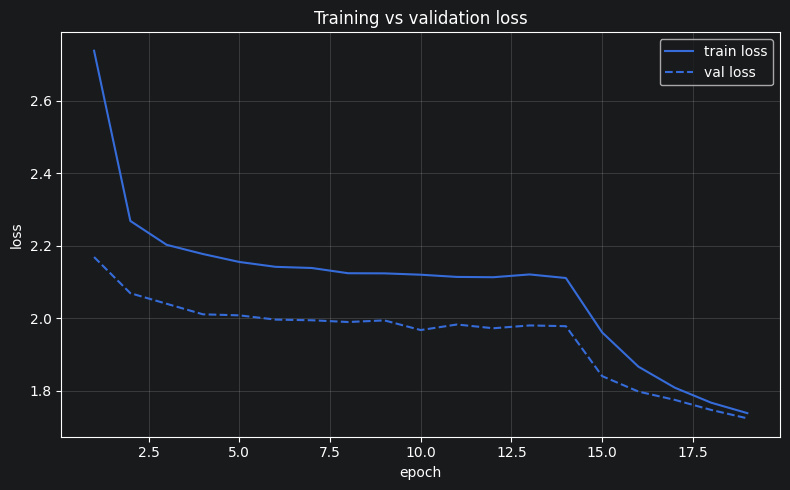

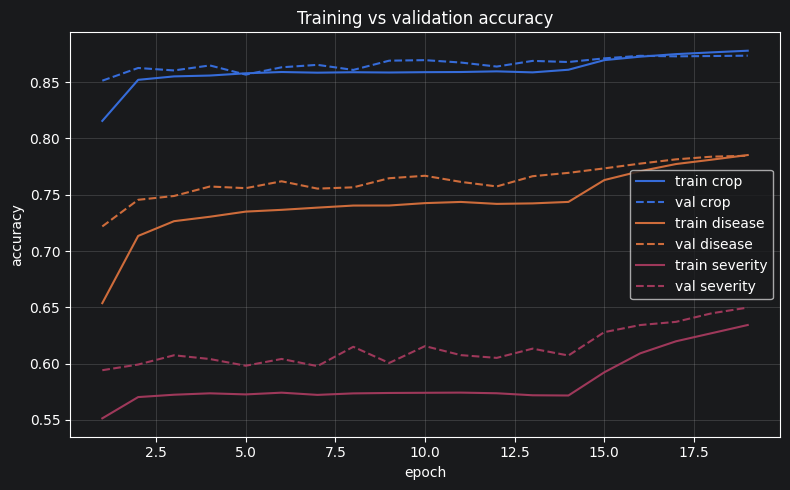

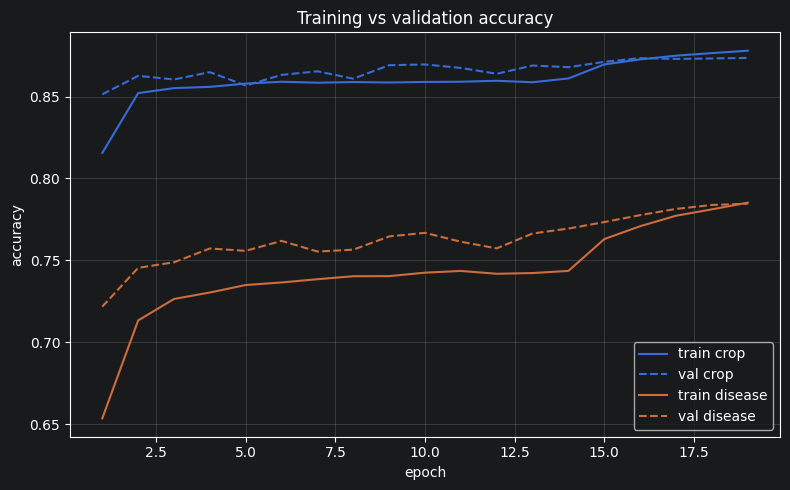

In [10]:
visual_model = VisualModel(classes=classes)
visual_model.build()
visual_model.compile()
history_frozen = visual_model.fit(train_ds, val_ds, epochs=20)
visual_model.unfreeze()
history_tuned = visual_model.fit(train_ds, val_ds, epochs=5)

visual_evaluator.plot_loss(history_frozen, history_tuned)
visual_evaluator.plot_accuracy(history_frozen, history_tuned)
visual_evaluator.plot_accuracy(history_frozen, history_tuned, heads=["crop", "disease"])

In [11]:
import json
Path("./models/visual_models/9_19_classes.json").write_text(json.dumps(classes))
visual_model.save(path="./models/visual_models/9_19.keras")

In [12]:
MODEL_DIR = Path("./models/visual_models")
IMAGES_ROOT = DATA_DIR / "PlantExpertVQA"

vm = VisualModel.load(MODEL_DIR / "9_19.keras", MODEL_DIR/"9_19_classes.json")

13:04:40 [INFO    ]: 

-------- Test_VisualMoel: evaluating 152921 images --------




2026-09-19 13:10:40.993836: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 13:10:41.135023: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 13:10:41.273847: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 13:10:41.631910: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-19 13:10:41.785120: E external/local_xla/xla/stream_

13:10:43 [INFO    ]: 
               n  accuracy  top3_accuracy  macro_f1  majority_baseline
head                                                                  
crop      152921     0.840          0.938     0.868              0.194
disease   152921     0.767          0.940     0.722              0.148
severity  152921     0.575          0.957     0.552              0.358
13:10:43 [INFO    ]: 
crop classification report:
                  precision    recall  f1-score   support

           apple       0.86      0.88      0.87      2841
 arabian jasmine       1.00      1.00      1.00       745
    bitter gourd       1.00      1.00      1.00       750
       blueberry       0.77      0.83      0.80      1080
    bottle gourd       1.00      0.99      0.99      1033
     cauliflower       1.00      0.99      0.99       148
          cherry       0.85      0.90      0.88      2257
          citrus       0.00      0.00      0.00      1765
            corn       0.96      0.99      0.97   

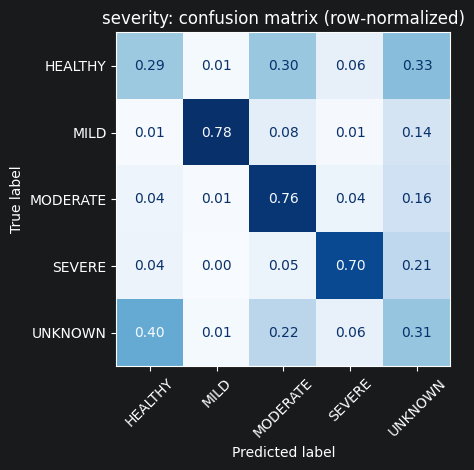

,n,accuracy,top3_accuracy,macro_f1,majority_baseline
head,,,,,
crop,152921,0.840,0.938,0.868,0.194
disease,152921,0.767,0.940,0.722,0.148
severity,152921,0.575,0.957,0.552,0.358


In [13]:
test_table, test_predictions = visual_evaluator.evaluate(vm, plant_expert_vqa_TEST, IMAGES_ROOT, name="Test_VisualMoel")
test_table